# Worksheet 2: Root finding
## - 23MS121 
## - Manish Behera

### Q1. 
(8 points) Numerically estimate f ′(x) for f (x) = sin(x) at x = 2π/5, using
(a) Forward difference: f ′
n ≈ (fn+1 − fn)/h
(b) Backward difference: f ′
n ≈ (fn − fn−1)/h
(c) Central difference: f ′
n ≈ (fn+1 − fn−1)/(2h)
(d) Five-point approximation: f ′
n ≈ (fn−2 − 8fn−1 + 8fn+1 − fn+2)/(12h)
for h = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001, 0.0005, 0.0002, 0.0001].
(a) (3 points) Create a table to record the estimate derivatives using different methods for each h.
(b) (3 points) Plot the differences between exact values and the estimated values (the error).
(c) (2 points) Fit the log of the error versus the log of h and compare the efficiencies of the methods.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

In [2]:
def f(x):
    return np.sin(x)

In [3]:
def forward_diff(f,xn,h):
    return (f(xn+h) - f(xn))/h
def backward_diff(f,xn,h):
    return (f(xn) - f(xn-h))/h
def central_diff(f,xn,h):
    return (f(xn+h) - f(xn-h))/(2*h)
def five_point_approx(f,xn,h):
    return (f(xn-2*h)-8*f(xn-h)+8*f(xn+h)-f(xn+2*h))/(12*h)

In [4]:
#create a table to record the estimate derivatives using different methods for each h.
hs = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001, 0.0005, 0.0002, 0.0001]

xn = 2*np.pi/5

exact = np.cos(xn)

forward_list = [forward_diff(f,xn,i) for i in hs]
backward_list = [backward_diff(f,xn,i) for i in hs]
central_list = [central_diff(f,xn,i) for i in hs]
five_point_list = [five_point_approx(f,xn,i) for i in hs]

tab = [forward_list,backward_list,central_list,five_point_list]

#print dataframe using pandas
column_names = [f'h={h}' for h in hs]
row_names = ["forward_diff","backward_diff","central_diff","five_point_approx"]

df = pd.DataFrame(tab, columns=column_names, index=row_names)
pd.set_option('display.precision', 6)
display(df)

,h=0.5,h=0.2,h=0.1,h=0.05,h=0.02,h=0.01,h=0.005,h=0.002,h=0.001,h=0.0005,h=0.0002,h=0.0001
forward_diff,0.063449,0.212172,0.260989,0.285117,0.299486,0.304257,0.306638,0.308066,0.308541,0.308779,0.308922,0.308969
backward_diff,0.529153,0.401750,0.356015,0.332660,0.318507,0.313767,0.311393,0.309968,0.309492,0.309255,0.309112,0.309065
central_diff,0.296301,0.306961,0.308502,0.308888,0.308996,0.309012,0.309016,0.309017,0.309017,0.309017,0.309017,0.309017
five_point_approx,0.308392,0.309001,0.309016,0.309017,0.309017,0.309017,0.309017,0.309017,0.309017,0.309017,0.309017,0.309017


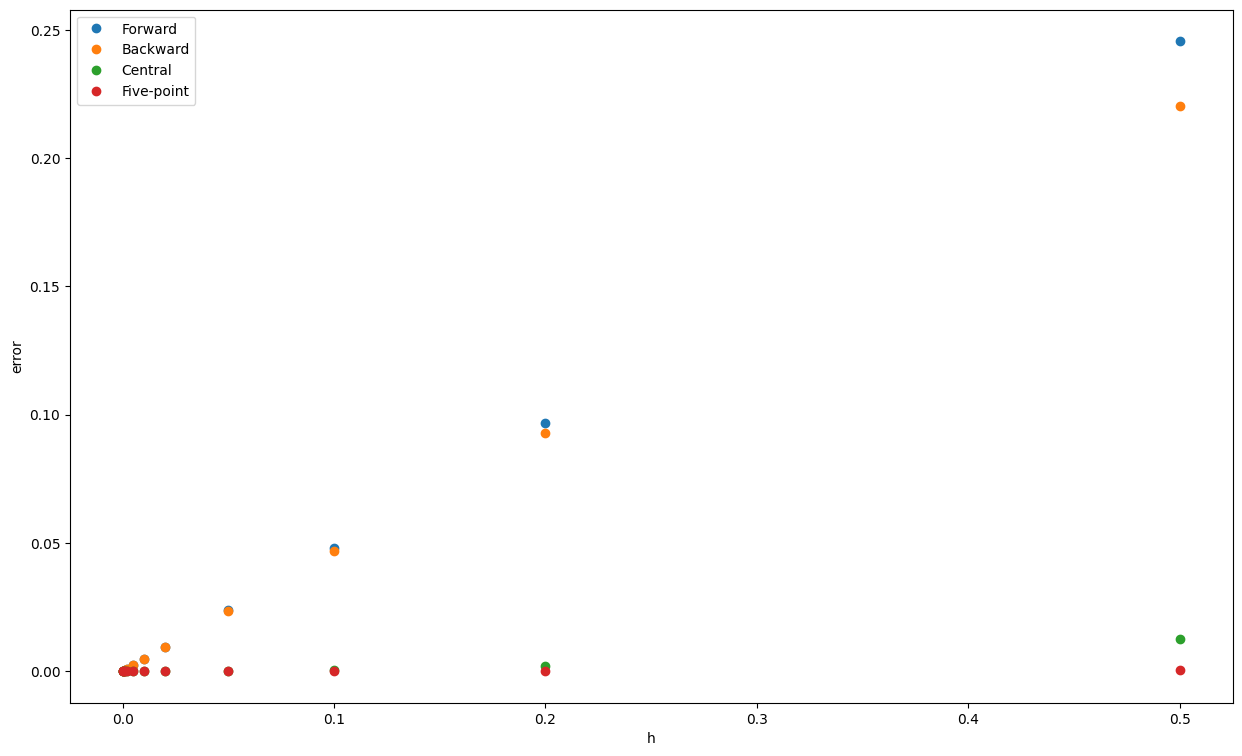

In [5]:
# plot the differences between exact values and the estimated values (the error).

calc_vals=[forward_list,backward_list,central_list,five_point_list]
descriptions = ["Forward","Backward","Central","Five-point"]
k = 0
plt.figure(figsize=(15, 9))
plt.xlabel("h")
plt.ylabel("error")
for vals in calc_vals:
    ys = [abs(i-exact) for i in vals]
    plt.plot(hs,ys,"o",label=descriptions[k])
    plt.legend()
    k += 1

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
C:\Users\mbsci\AppData\Local\Temp\ipykernel_20420\2652903094.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\log_{10}(h)$')
C:\Users\mbsci\AppData\Local\Temp\ipykernel_20420\2652903094.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(\text{error})$')


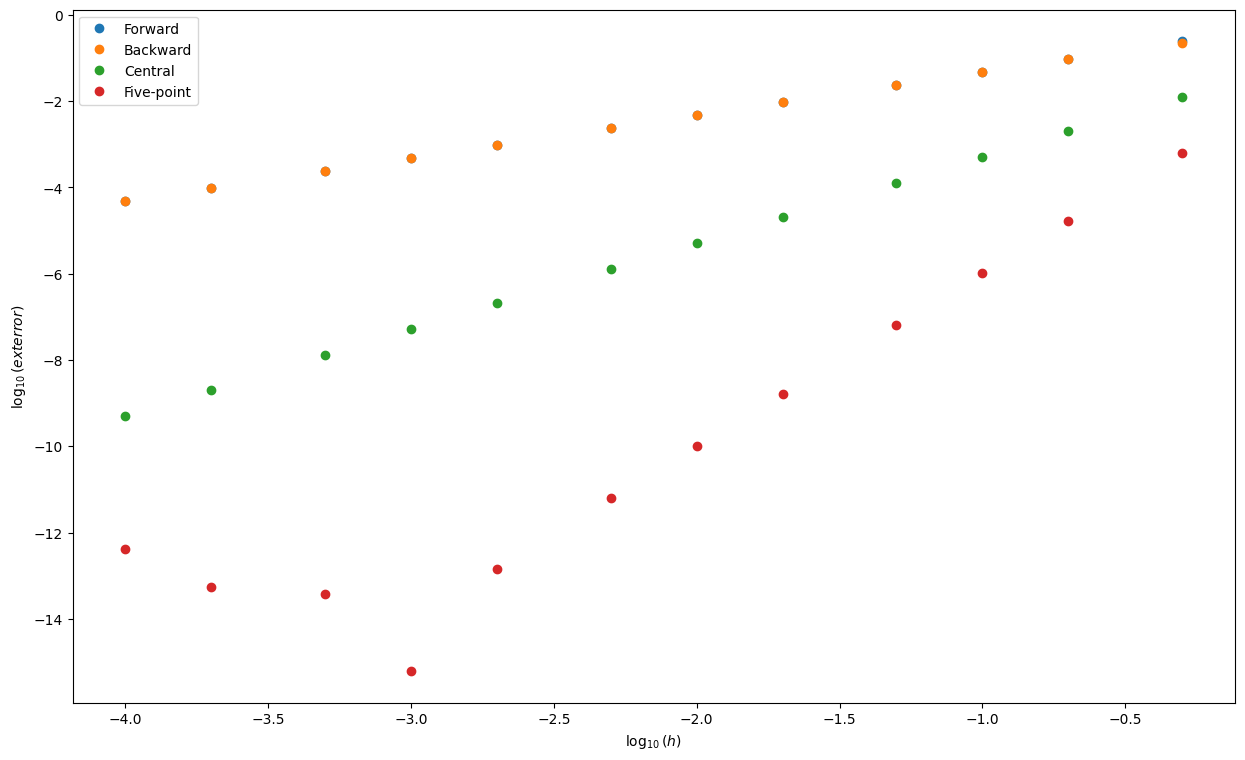

In [6]:
#fit the log of the error versus the log of h and compare the efficiencies of the methods.

descriptions = ["Forward","Backward","Central","Five-point"]
k = 0
plt.figure(figsize=(15, 9))
plt.xlabel('$\log_{10}(h)$')
plt.ylabel('$\log_{10}(\text{error})$')
for vals in calc_vals:
    ys = [abs(i-exact) for i in vals]
    plt.plot(np.log10(hs),np.log10(ys),"o",label=descriptions[k])
    plt.legend()
    k += 1


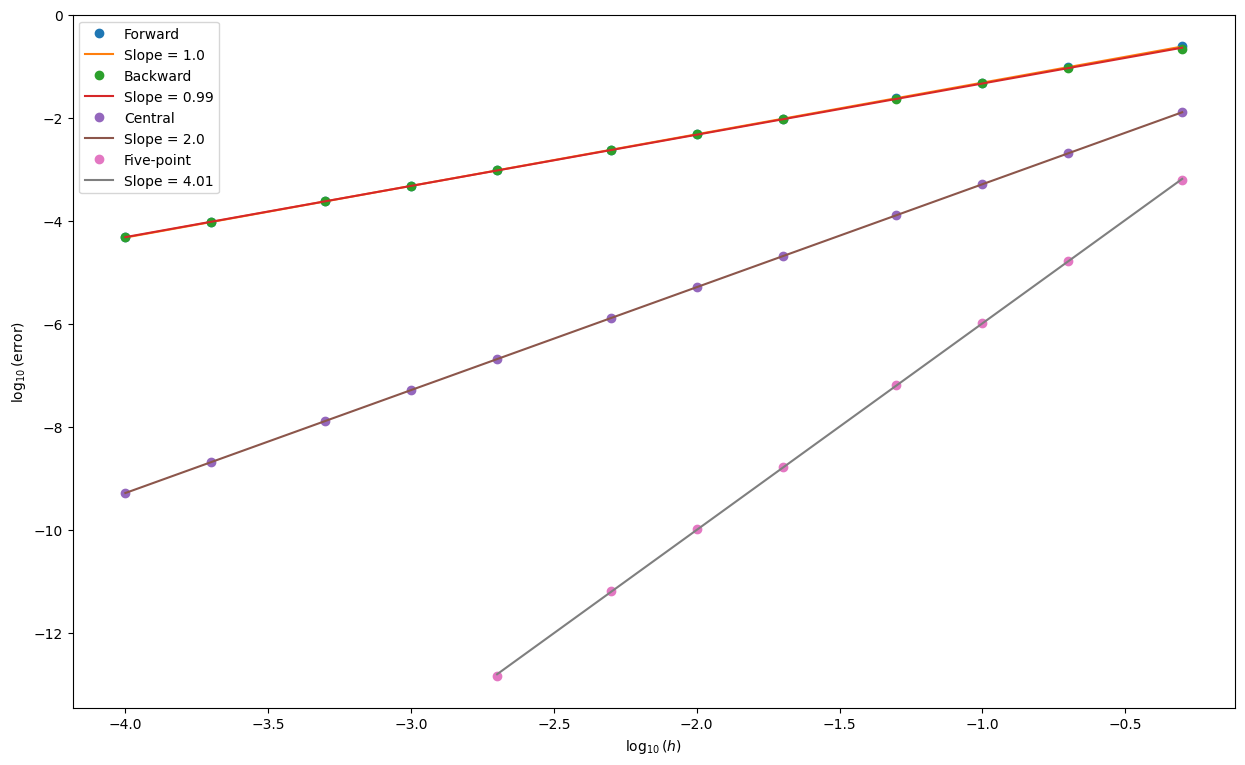

In [8]:
def eq_of_line(xs, p0, p1):
    return p0*xs+p1

k = 0
plt.figure(figsize=(15, 9))
plt.xlabel(r'$\log_{10}(h)$')
plt.ylabel(r'$\log_{10}(\text{error})$')
for vals in calc_vals:
    ys = np.log10([abs(i-exact) for i in vals])
    xs = np.log10(hs)
    if k==3:  # avoid fitting the rise in error in five-point
        numdata = 8
    else:
        numdata = len(hs)
    xs = xs[:numdata]
    ys = ys[:numdata]
    plt.plot(xs,ys,"o",label=descriptions[k])
    params, covariance = curve_fit(eq_of_line, xs, ys, p0=[1.0, 1.0]) #do not need covar_mat, need only params
    plt.plot(xs, eq_of_line(xs, params[0], params[1]),label="Slope = "+str(round(params[0],2))) #plt line
    plt.legend()
    k += 1

### Q2. 

(8 points) 
Numerically estimate R 10 f (x)dx for f (x) = ex, using the following methods:

(a) Linear (Trapezoidal): R x3
x1 f (x)dx = h
2 (f1 + 2f2 + f3) + O(h3)
(b) Quadratic (Simpson’s 1
3 rule): R x3
x1 f (x)dx = h
3 (f1 + 4f2 + f3) + O(h5)
(c) Cubic (Simpson’s 3
8 rule): R x4
x1 f (x)dx = 3h
8 (f1 + 3f2 + 3f3 + f4) + O(h5)
(d) Quartic (Boole’s rule): R x5
x1 f (x)dx = 2h
45 (7f1 + 32f2 + 12f3 + 32f4 + 7f5) + O(h7)

(a) (4 points) Consider the interval [0, 1). Choose m from [4, 8, 16, 32, 64]. For trapezoidal and

Simpson’s 1/3, N = 2m + 1. For Simpson’s 3/8, N = 3m + 1 and for Boole’s method N =
4m + 1. Create a table to record the estimate integral using different methods for each h =
(1.0 − 0.0)/(N − 1) value.
(b) (2 points) Plot the differences between exact values and the estimated values (the error).
(c) (2 points) Fit the log of the error versus the log of h and compare the efficiencies of the methods.

In [9]:
def f(x):
    return np.exp(x)

exact = np.exp(1)-1
print(exact)

1.718281828459045


In [10]:
range = [0,1] #definite integral bounds 
N = 10 #number of steps 
h = (range[1]-range[0])/N

##### Linear (Trapezoidal)

In [11]:
import numpy as np

def int_trap(f, x_min, x_max, N):
    h = (x_max - x_min) / N
    x = np.linspace(x_min, x_max, N + 1)
    y = f(x)
    # The sum of interior points (indices 1 to N-1) multiplied by 2, 
    # plus the endpoints (indices 0 and N) multiplied by 1.
    integral = (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])
    return integral
print(int_trap(f,0,1,100))

1.7182961474504177


##### Quadratic (Simpson’s $\frac{1}{3}$ rule)

In [12]:
def int_simpson13(f,x_min,x_max,N):
    if N % 2 != 0: 
        print("N must be even")
        return None
        
    h = (x_max - x_min) / N
    x = np.linspace(x_min, x_max, N + 1)
    y = f(x)
    
    # 4 * sum of odd indx terms (y1, y3, ..., yN-1)
    sum_odd = np.sum(y[1:-1:2])
    # 2 * sum of even indx terms (y2, y4, ..., yN-2)
    sum_even = np.sum(y[2:-1:2])
    
    # Formula: (h/3) * [f(x0) + 4*sum_odd + 2*sum_even + f(xn)]
    return (h / 3) * (y[0] + y[-1] + 4 * sum_odd + 2 * sum_even)
print(int_simpson13(f,0,1,100))

1.7182818285545045


###### Cubic (Simpson’s $\frac{3}{8}$ rule)

In [13]:
def int_simpson38(f,x_min,x_max,N):
    if N % 3 != 0:
        print("N must be a multiple of 3")
        return None
    
    h = (x_max - x_min) / N
    x = np.linspace(x_min, x_max, N + 1)
    y = f(x)

    internal_idx = np.arange(1, N)
    # Multiples of 3 get weight 2; all others get weight 3
    weights = np.where(internal_idx % 3 == 0, 2, 3)
    
    # Formula: (3h/8) * [f(x0) + f(xn) + sum(weights * internal_f_values)]
    total_sum = y[0] + y[-1] + np.sum(weights * y[1:-1])
    return (3 * h / 8) * total_sum
print(int_simpson38(f,0,1,300))

1.7182818284616974


#### Quartic (Boole’s rule)

In [14]:
def int_bool(f, x_min, x_max, N):
    if N % 4 != 0:
        print("N must be a multiple of 4")
        return None
    
    h = (x_max - x_min) / N
    x = np.linspace(x_min, x_max, N + 1)
    y = f(x)
    
    # weights: 
    # odd get 32
    # mid-segment get 12
    # segment boundaries get 14
    internal_idx = np.arange(1, N)
    weights = np.zeros(N - 1)
    
    weights[0::2] = 32
    weights[1::4] = 12     
    weights[3::4] = 14        
    total_sum = 7*y[0] + 7*y[-1] + np.sum(weights * y[1:-1])
    return (2 * h / 45) * total_sum
print(int_bool(f,0,1,100))

1.718281828459049


In [15]:
ms = [4, 8, 16, 32, 64]

N_ts13 = [2*i+1 for i in ms]
N_s38 = [3*i+1 for i in ms]
N_B = [4*i+1 for i in ms]